# SISSO Equation Post-Processing Tool

**PURPOSE**: This notebook evaluates SISSO symbolic regression equations to:
1. Calculate predictions on material property datasets
2. Assess model performance with statistical metrics (R², RMSE, MAE)
3. Generate publication-quality parity plots
4. Export detailed results and visualizations

**REQUIREMENTS**:
* Python 3.12+
* Libraries: pandas (2.2.3), matplotlib (3.9.2), numpy (1.26.4), scikit-learn (1.5.2), colorama (0.4.6), openpyxl
* Input file: `SISSO_post-processing_input.xlsx` with property sheets, and `symbol_conversion.txt` with LaTeX symbol info
* Supported input formats: .csv, .xls, .xlsx

**USAGE**:
1. Run the notebook cells sequentially
2. Follow the interactive prompts to:
   * Load your Excel file and select property sheet
   * Choose formula, actual values, and parameter columns
   * Enter SISSO equation with coefficients
   * Validate equation on sample data
   * Specify output location and filenames
   * 
Outputs: PDF scatter plot, Excel workbook (Predictions + Summary sheets) - Saved in SISSO_post_processing_results

**NOTE**: Use `**` for exponentiation (not `^`) in equations.



    SISSO POSTPROCESSING TOOL


 DATA LOADING 



Enter folder path containing the data file:  C:\


[OK] Path found: C:\
[OK] Found 3 file(s):
  1. AFLOW_cleaned_dataset.csv
  2. MP_cleaned_dataset.csv
  3. SISSO_postprocessing_input_data.xlsx


Enter file number:  3



Select sheet:
  1. Debye_temperature
  2. Cp (300 K)
  3. thermal_conductivity (300 K) 


...


 COMPUTING PREDICTIONS 

[OK] Predictions computed: n=6276, range=[3.1431e+01, 1.6723e+03]

 OUTPUT SETUP 



Enter directory to save results:  C:\


[OK] Path found: C:\


File prefix (e.g. 'run1'):  DT_MP


[OK] Output directory: C:\SISSO_post_processing_results\DT_MP_Results

 CREATING PLOT 

[OK] Plot saved: C:\SISSO_post_processing_results\DT_MP_Results\DT_MP_prediction_plot.pdf


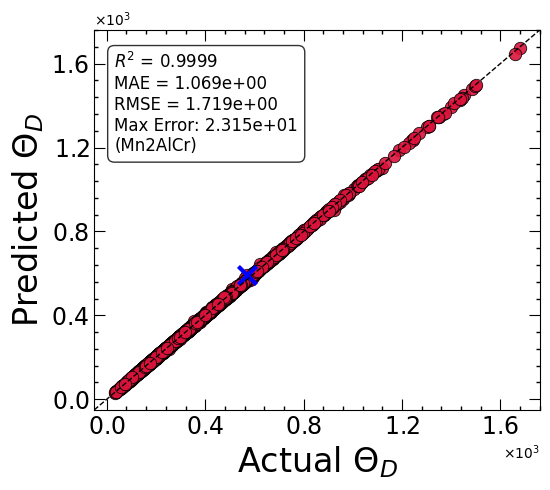


 SAVING RESULTS 

[OK] Results saved: C:\SISSO_post_processing_results\DT_MP_Results\DT_MP_results.xlsx

R²   = 0.999902
RMSE = 1.718759e+00
MAE  = 1.069026e+00
Max Error = 2.315408e+01 (Mn2AlCr)



[OK] ============================================================
[OK]     ANALYSIS COMPLETE
[OK] ============================================================

[OK] Input  : C:\SISSO_postprocessing_input_data.xlsx  [sheet: Debye_temperature]
[OK] Plot   : C:\SISSO_post_processing_results\DT_MP_Results\DT_MP_prediction_plot.pdf
[OK] Results: C:\SISSO_post_processing_results\DT_MP_Results\DT_MP_results.xlsx



In [4]:
import os
import re
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator, ScalarFormatter
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from colorama import init, Fore, Style, Back

init(autoreset=True)
plt.rcParams["font.family"] = "sans-serif"


# ──────────────────────────────────────────────
# Console helpers
# ──────────────────────────────────────────────

def _print(tag: str, color: str, text: str) -> None:
    print(f"{color}[{tag}] {text}{Style.RESET_ALL}")

def print_header(text: str) -> None:
    print(f"\n{Back.BLUE}{Fore.WHITE}{Style.BRIGHT} {text} {Style.RESET_ALL}\n")

def print_success(text: str) -> None: _print("OK",      Fore.GREEN, text)
def print_error(text: str)   -> None: _print("ERROR",   Fore.RED,     text)
def print_warning(text: str) -> None: _print("WARNING", Fore.YELLOW,  text)
def print_info(text: str)    -> None: _print("INFO",    Fore.MAGENTA,   text)

def is_yes(raw: str) -> bool:
    """Return True for any recognisable affirmative: y / Y / yes / Yes / YES."""
    return raw.strip().lower() == "y" or raw.strip().lower() == "yes"


# ──────────────────────────────────────────────
# Input helpers
# ──────────────────────────────────────────────

def get_valid_path(prompt: str, must_exist: bool = True) -> str | None:
    """Prompt for a filesystem path, optionally verifying it exists."""
    while True:
        raw = input(f"{Fore.GREEN}{prompt}{Style.RESET_ALL}").strip().strip("\"'")
        if not raw:
            print_error("Path cannot be empty.")
            continue
        p = Path(raw)
        if must_exist and not p.exists():
            print_error(f"Path not found: {p}")
            if not is_yes(input(f"{Fore.YELLOW}Try again? (y/n): {Style.RESET_ALL}")):
                return None
        else:
            print_success(f"Path found: {p}")
            return str(p)


def get_valid_float(prompt: str) -> float:
    """Prompt until the user supplies a valid float."""
    while True:
        raw = input(f"{Fore.GREEN}{prompt}{Style.RESET_ALL}").strip()
        try:
            return float(raw)
        except ValueError:
            print_error(f"'{raw}' is not a valid number.")


def get_valid_int(prompt: str, min_val: int = None, max_val: int = None) -> int:
    """Prompt until the user supplies a valid integer within optional bounds."""
    while True:
        raw = input(f"{Fore.CYAN}{prompt}{Style.RESET_ALL}").strip()
        try:
            val = int(raw)
        except ValueError:
            print_error(f"'{raw}' is not a valid integer.")
            continue
        if min_val is not None and val < min_val:
            print_error(f"Value must be ≥ {min_val}.")
            continue
        if max_val is not None and val > max_val:
            print_error(f"Value must be ≤ {max_val}.")
            continue
        return val


def get_valid_string(prompt: str) -> str:
    """Prompt until the user supplies a non-empty string."""
    while True:
        raw = input(f"{Fore.GREEN}{prompt}{Style.RESET_ALL}").strip()
        if raw:
            return raw
        print_error("Input cannot be empty.")


def select_from_list(items: list, prompt: str):
    """Display a numbered list and return the user's chosen item."""
    print(f"\n{Fore.YELLOW}{prompt}{Style.RESET_ALL}")
    for i, item in enumerate(items, 1):
        print(f"  {Fore.CYAN}{i}.{Style.RESET_ALL} {item}")
    idx = get_valid_int(f"Enter choice (1–{len(items)}): ", min_val=1, max_val=len(items))
    return items[idx - 1]


# ──────────────────────────────────────────────
# Excel export
# ──────────────────────────────────────────────

def write_df_to_sheet(ws, df: pd.DataFrame, start_row: int = 1) -> None:
    """
    Write a DataFrame to an openpyxl worksheet.
    Applies a dark-blue header row and thin borders throughout.
    """
    HEADER_FILL = PatternFill("solid", fgColor="1F4E79")
    HEADER_FONT = Font(bold=True, color="FFFFFF", name="Arial", size=11)
    DATA_FONT   = Font(name="Arial", size=11)
    CENTER      = Alignment(horizontal="center", vertical="center")
    THIN        = Side(style="thin", color="000000")
    BORDER      = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)

    for col_idx, col_name in enumerate(df.columns, 1):
        cell = ws.cell(row=start_row, column=col_idx, value=col_name)
        cell.font, cell.fill, cell.alignment, cell.border = (
            HEADER_FONT, HEADER_FILL, CENTER, BORDER
        )

    for row_idx, row in enumerate(df.itertuples(index=False), start_row + 1):
        for col_idx, value in enumerate(row, 1):
            cell = ws.cell(row=row_idx, column=col_idx, value=value)
            cell.font, cell.alignment, cell.border = DATA_FONT, CENTER, BORDER

    # Auto-size columns based on content width
    for col_idx, col_name in enumerate(df.columns, 1):
        col_values = [
            ws.cell(row=r, column=col_idx).value
            for r in range(start_row + 1, start_row + 1 + len(df))
        ]
        max_len = max(
            len(str(col_name)),
            max((len(str(v or "")) for v in col_values), default=0),
        )
        ws.column_dimensions[get_column_letter(col_idx)].width = min(max_len + 4, 50)


# ──────────────────────────────────────────────
# Symbol map  (column name → LaTeX/display label)
# ──────────────────────────────────────────────

def load_symbol_map(base_path: str) -> dict:
    """
    Optionally load a symbol_conversion.txt file that maps column names to
    LaTeX-formatted axis labels.

    File format (one entry per line):
        COLUMN_NAME = $LaTeX_expression$
    Lines that are blank or contain no '=' are silently skipped.
    """
    print_header("SYMBOL CONFIGURATION")
    if not is_yes(input(
        f"{Fore.YELLOW}Use symbol_conversion.txt for axis labels? (y/n): {Style.RESET_ALL}"
    )):
        print_info("Using raw column names for axis labels.")
        return {}

    if is_yes(input(
        f"{Fore.YELLOW}Is symbol_conversion.txt in the same folder as the data file? (y/n): {Style.RESET_ALL}"
    )):
        symbol_path = os.path.join(base_path, "symbol_conversion.txt")
    else:
        symbol_path = input(
            f"{Fore.MAGENTA}Enter full path to symbol_conversion.txt: {Style.RESET_ALL}"
        ).strip()

    if not os.path.exists(symbol_path):
        print_error(f"File not found: {symbol_path}. Using raw column names.")
        return {}

    symbol_map: dict = {}
    try:
        with open(symbol_path) as f:
            for line in f:
                line = line.strip()
                if not line or "=" not in line:
                    continue
                key, val = line.split("=", 1)
                symbol_map[key.strip()] = val.strip()
        print_success(f"Loaded {len(symbol_map)} symbol mappings.")
    except Exception as e:
        print_error(f"Could not read symbol file: {e}. Using raw column names.")
    return symbol_map


# ──────────────────────────────────────────────
# Data loading
# ──────────────────────────────────────────────

def load_data() -> tuple | None:
    """
    Prompt the user to select a data file (.csv / .xls / .xlsx) and return
    (file_path, sheet_name, DataFrame, directory).
    Returns None on failure.
    """
    print_header("DATA LOADING")
    file_dir = get_valid_path("Enter folder path containing the data file: ")
    if not file_dir:
        return None

    supported = (".csv", ".xls", ".xlsx")
    all_files = sorted(f for f in os.listdir(file_dir) if f.endswith(supported))

    if not all_files:
        print_error("No supported files (.csv, .xls, .xlsx) found in that directory.")
        return None

    print_success(f"Found {len(all_files)} file(s):")
    for i, f in enumerate(all_files, 1):
        print(f"  {i}. {f}")

    choice = get_valid_int("Enter file number: ", min_val=1, max_val=len(all_files))
    file_name = all_files[choice - 1]
    file_path = str(Path(file_dir) / file_name)

    try:
        if file_name.endswith((".xls", ".xlsx")):
            xls = pd.ExcelFile(file_path)
            sheet_name = select_from_list(xls.sheet_names, "Select sheet:")
            df = pd.read_excel(file_path, sheet_name=sheet_name)
        else:
            sheet_name = "CSV"
            df = pd.read_csv(file_path)
    except Exception as e:
        print_error(f"Could not read file: {e}")
        return None

    print_success(f"Loaded {len(df)} rows × {len(df.columns)} columns.")
    print_info("Columns: " + ", ".join(df.columns))
    return file_path, sheet_name, df, file_dir


# ──────────────────────────────────────────────
# Column selection
# ──────────────────────────────────────────────

def select_columns(df: pd.DataFrame) -> tuple[str, str, list[str]]:
    """
    Interactively select the formula identifier column, the target (actual)
    column, and one or more predictor (parameter) columns.
    """
    print_header("COLUMN SELECTION")
    columns = list(df.columns)

    formula_col = select_from_list(columns, "Select the chemical FORMULA column:")
    actual_col  = select_from_list(columns, "Select the TARGET PROPERTY column:")

    remaining = [c for c in columns if c not in (formula_col, actual_col)]
    print(f"\n{Fore.YELLOW}Select PREDICTOR columns (comma-separated numbers):{Style.RESET_ALL}")
    for i, col in enumerate(columns, 1):
        if col in remaining:
            print(f"  {Fore.GREEN}{i}.{Style.RESET_ALL} {col}")

    while True:
        raw = input(f"{Fore.CYAN}Enter column numbers: {Style.RESET_ALL}").strip()
        try:
            indices   = [int(x) - 1 for x in raw.split(",")]
            param_cols = [columns[i] for i in indices if 0 <= i < len(columns)]
        except (ValueError, IndexError):
            print_error("Invalid input. Use comma-separated integers from the list above.")
            continue
        if not param_cols:
            print_error("No valid columns selected.")
            continue
        print_success(f"Selected: {', '.join(param_cols)}")
        if is_yes(input(f"{Fore.YELLOW}Confirm? (y/n): {Style.RESET_ALL}")):
            return formula_col, actual_col, param_cols


# ──────────────────────────────────────────────
# Equation input & preprocessing
# ──────────────────────────────────────────────

def preprocess_equation(equation: str) -> tuple[str, str]:
    """
    Convert a human-friendly math expression to valid Python/NumPy syntax.

    Transformations applied (in order):
      - '^' exponentiation → '**'  (with special-case for 'exp^(')
      - math functions (exp, sqrt, cbrt, log, log10, sin, cos, tan, abs)
        → numpy equivalents
      - '|expr|' absolute-value notation → np.abs(expr)
    """
    original = equation

    # Handle 'exp^(' before replacing bare '^'
    equation = re.sub(r"exp\s*\^\s*\(", "EXP_POWER(", equation)
    equation = equation.replace("^", "**")
    equation = equation.replace("EXP_POWER(", "np.exp(")

    # Unary minus variant: 'exp-('  →  'np.exp(-('
    equation = re.sub(r"exp-\s*\(", "np.exp(-(", equation)

    _fn_map = {
        "exp": "np.exp", "sqrt": "np.sqrt", "cbrt": "np.cbrt",
        "log10": "np.log10", "log": "np.log",
        "sin": "np.sin", "cos": "np.cos", "tan": "np.tan",
        "abs": "np.abs",
    }
    for fn, np_fn in _fn_map.items():
        equation = re.sub(rf"\b{fn}\s*\(", f"{np_fn}(", equation)

    # Pipe-notation absolute value  |expr|  →  np.abs(expr)
    equation = re.sub(r"\|([^|]+)\|", r"np.abs(\1)", equation)

    return equation, original


def get_sisso_equation(param_cols: list[str]) -> tuple[str, dict, str, str]:
    """
    Interactively collect the SISSO equation and its numeric coefficients.

    Returns
    -------
    equation         : preprocessed (Python-eval-ready) equation string
    coeff_values     : dict mapping coefficient names (c0, c1, …) to floats
    equation_original: human-readable equation with coefficient placeholders
    display_equation : human-readable equation with numeric values substituted
    """
    OPERATORS_HELP = (
        "\nBasic : +  -  *  /  ** (or ^)\n"
        "Funcs : exp  sqrt  cbrt  log  log10  abs  |x|\n"
        "Trig  : sin  cos  tan\n"
        f"Example: c0 + c1*exp({param_cols[0]}) + c2*sqrt({param_cols[min(1, len(param_cols)-1)]})"
    )

    while True:
        print_header("SISSO EQUATION INPUT")
        print_info(f"Available parameters: {', '.join(param_cols)}")

        c0 = get_valid_float("  c0 = ")
        c1 = get_valid_float("  c1 = ")
        coeff_values: dict = {"c0": c0, "c1": c1}
        coeff_num = 2

        if is_yes(input(f"  {Fore.YELLOW}Additional coefficients?  (eg. c2, c3 etc.) (y/n): {Style.RESET_ALL}")):
            while True:
                raw = input(f"  c{coeff_num} (Enter to finish): ").strip()
                if not raw:
                    break
                try:
                    coeff_values[f"c{coeff_num}"] = float(raw)
                    coeff_num += 1
                except ValueError:
                    print_error("Invalid number.")

        print(f"{Fore.YELLOW}{OPERATORS_HELP}{Style.RESET_ALL}")
        eq_input = get_valid_string("Enter equation (using c0, c1, … and parameter names): ")

        display_eq = eq_input
        for name, val in coeff_values.items():
            display_eq = display_eq.replace(name, str(val))

        print_success("Equation summary:")
        print(f"  Symbolic : {eq_input}")
        print(f"  Numeric  : {display_eq}")

        if is_yes(input(f"{Fore.YELLOW}Correct? (y/n): {Style.RESET_ALL}")):
            break
        print_info("Re-entering equation …\n")

    processed_eq, original_eq = preprocess_equation(eq_input)

    # Prompt for any coefficients referenced in the equation but not yet defined
    missing = [
        c for c in re.findall(r"\b[cC]\d+\b", eq_input)
        if c.lower() not in coeff_values
    ]
    for coeff in sorted(set(missing)):
        print_warning(f"No value provided for '{coeff}'.")
        coeff_values[coeff.lower()] = get_valid_float(f"  {coeff} = ")

    return processed_eq, coeff_values, original_eq, display_eq


# ──────────────────────────────────────────────
# Equation evaluation
# ──────────────────────────────────────────────

def _build_eval_namespace(df: pd.DataFrame, param_cols: list[str], coeff_values: dict) -> dict:
    """
    Build a safe eval namespace containing NumPy, math aliases, column arrays,
    and coefficient values.  __builtins__ is excluded from the eval call itself.
    """
    ns: dict = {col: df[col].values for col in param_cols}
    ns.update(coeff_values)
    ns["np"]    = np
    ns["exp"]   = np.exp
    ns["sqrt"]  = np.sqrt
    ns["cbrt"]  = getattr(np, "cbrt", lambda x: np.power(x, 1 / 3))
    ns["log"]   = np.log
    ns["log10"] = np.log10
    ns["sin"]   = np.sin
    ns["cos"]   = np.cos
    ns["tan"]   = np.tan
    ns["abs"]   = np.abs
    return ns


def test_equation(
    df: pd.DataFrame,
    param_cols: list[str],
    equation: str,
    coeff_values: dict,
    n_samples: int = 3,
) -> bool:
    """
    Evaluate the preprocessed equation on the first n_samples rows to catch
    syntax errors or mismatched column names before the full run.
    """
    print_header("EQUATION VALIDATION")
    try:
        ns      = _build_eval_namespace(df[param_cols].head(n_samples), param_cols, coeff_values)
        results = eval(equation, {"__builtins__": {}}, ns)
        print_success(f"Equation evaluated successfully on {n_samples} sample rows.")
        for i, val in enumerate(results[:n_samples]):
            row_info = {col: df[param_cols].iloc[i][col] for col in param_cols}
            print(f"  Sample {i+1}: params={row_info}  →  predicted={val:.6e}")
        return True
    except Exception as e:
        print_error(f"Equation evaluation failed: {e}")
        traceback.print_exc()
        return False


def compute_predictions(
    df: pd.DataFrame, param_cols: list[str], equation: str, coeff_values: dict
) -> np.ndarray | None:
    """
    Evaluate the SISSO equation over the entire DataFrame and return predictions.
    Returns None on any evaluation error.
    """
    print_header("COMPUTING PREDICTIONS")
    try:
        ns     = _build_eval_namespace(df, param_cols, coeff_values)
        y_pred = eval(equation, {"__builtins__": {}}, ns)
        y_pred = np.asarray(y_pred, dtype=float)
        print_success(f"Predictions computed: n={len(y_pred)}, "
                      f"range=[{y_pred.min():.4e}, {y_pred.max():.4e}]")
        return y_pred
    except NameError as e:
        print_error(f"Unknown variable in equation: {e}")
        print_info(f"Available parameters: {', '.join(param_cols)}")
    except SyntaxError as e:
        print_error(f"Equation syntax error: {e}")
    except ZeroDivisionError:
        print_error("Division by zero encountered in equation.")
    except Exception as e:
        print_error(f"Unexpected error during evaluation: {e}")
        traceback.print_exc()
    return None


# ──────────────────────────────────────────────
# Metrics
# ──────────────────────────────────────────────

def calculate_metrics(
    y_actual: np.ndarray, y_pred: np.ndarray, formulas: np.ndarray
) -> dict:
    """
    Compute R², RMSE, MAE, and identify the compound with the largest absolute error.
    """
    errors  = np.abs(y_actual - y_pred)
    max_idx = int(np.argmax(errors))
    return {
        "r2":               r2_score(y_actual, y_pred),
        "rmse":             float(np.sqrt(mean_squared_error(y_actual, y_pred))),
        "mae":              float(mean_absolute_error(y_actual, y_pred)),
        "max_error":        float(errors[max_idx]),
        "max_error_formula": formulas[max_idx],
        "max_error_idx":    max_idx,
        "errors":           errors,
    }


# ──────────────────────────────────────────────
# Plotting
# ──────────────────────────────────────────────

def _axis_limits(y_actual: np.ndarray, y_pred: np.ndarray, pad: float = 0.05) -> tuple:
    """Return symmetric axis limits with fractional padding around the data range."""
    all_vals = np.concatenate([y_actual, y_pred])
    span = all_vals.ptp()  # peak-to-peak (max - min)
    return all_vals.min() - span * pad, all_vals.max() + span * pad


def create_plot(
    y_actual: np.ndarray,
    y_pred: np.ndarray,
    formulas: np.ndarray,
    metrics: dict,
    property_label: str,
    save_path: str,
) -> None:
    """
    Generate and save a parity (actual vs predicted) scatter plot.

    The compound with the largest error is highlighted with a blue cross.
    Regression statistics are displayed in an inset text box.
    """
    print_header("CREATING PLOT")

    fig, ax = plt.subplots(figsize=(5.6, 5))

    ax.scatter(y_actual, y_pred, s=80, color="crimson", alpha=0.9,
               edgecolors="k", linewidths=0.6, label="SISSO Prediction")

    # Highlight worst-case compound
    ax.scatter(
        y_actual[metrics["max_error_idx"]],
        y_pred[metrics["max_error_idx"]],
        color="blue", s=170, marker="x",
        linewidths=3, label="Max Error",
    )

    # Annotation box with key metrics
    info = (
        f"$R^2$ = {metrics['r2']:.4f}\n"
        f"MAE = {metrics['mae']:.3e}\n"
        f"RMSE = {metrics['rmse']:.3e}\n"
        f"Max Error: {metrics['max_error']:.3e}\n"
        f"({metrics['max_error_formula']})"
    )
    ax.annotate(info, xy=(0.045, 0.941), xycoords="axes fraction",
                fontsize=12, ha="left", va="top",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

    lo, hi = _axis_limits(y_actual, y_pred)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="Ideal")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_xlabel(f"Actual {property_label}", fontsize=24)
    ax.set_ylabel(f"Predicted {property_label}", fontsize=24)

    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(MaxNLocator(nbins=6))
        axis.set_major_formatter(ScalarFormatter(useMathText=True))
        axis.set_minor_locator(AutoMinorLocator(5))

    ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
    ax.tick_params(which="major", direction="in", labelsize=17, length=8,
                   left=True, right=True, top=True, bottom=True)
    ax.tick_params(which="minor", direction="in", length=3, width=1.0,
                   left=True, right=True, top=True, bottom=True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=800, bbox_inches="tight")
    print_success(f"Plot saved: {save_path}")
    plt.show()


# ──────────────────────────────────────────────
# Results export
# ──────────────────────────────────────────────

def save_results(
    df: pd.DataFrame,
    actual_col: str,
    y_pred: np.ndarray,
    metrics: dict,
    property_name: str,
    output_path: str,
    display_equation: str = "N/A",
) -> None:
    """
    Write two sheets to an Excel workbook:
      • Predictions — original data plus predicted values, absolute and relative errors
      • Summary     — equation, data count, and regression metrics
    """
    print_header("SAVING RESULTS")

    results_df = df.copy()
    results_df["SISSO_Prediction"] = y_pred
    results_df["Absolute_Error"]   = metrics["errors"]
    results_df["Relative_Error_%"] = (
        metrics["errors"] / np.abs(df[actual_col].values) * 100
    )

    summary_df = pd.DataFrame({
        "Metric": [
            "Property", "Equation", "N", "R²", "RMSE", "MAE",
            "Max Error", "Max Error Formula",
        ],
        "Value": [
            property_name, display_equation, len(df),
            round(metrics["r2"],        6),
            round(metrics["rmse"],      6),
            round(metrics["mae"],       6),
            round(metrics["max_error"], 6),
            metrics["max_error_formula"],
        ],
    })

    wb = Workbook()
    wb.remove(wb.active)
    write_df_to_sheet(wb.create_sheet("Predictions"), results_df)
    write_df_to_sheet(wb.create_sheet("Summary"),     summary_df)

    try:
        wb.save(output_path)
        print_success(f"Results saved: {output_path}")
    except Exception as e:
        print_error(f"Could not save workbook: {e}")
        return

    print(
        f"\n{'='*50}\n"
        f"R²   = {metrics['r2']:.6f}\n"
        f"RMSE = {metrics['rmse']:.6e}\n"
        f"MAE  = {metrics['mae']:.6e}\n"
        f"Max Error = {metrics['max_error']:.6e} ({metrics['max_error_formula']})\n"
        f"{'='*50}\n"
    )


# ──────────────────────────────────────────────
# Main
# ──────────────────────────────────────────────

def main() -> None:
    print(f"\n{Back.MAGENTA}{Fore.BLACK}{Style.BRIGHT}")
    print("=" * 60)
    print("    SISSO POSTPROCESSING TOOL")
    print("=" * 60)
    print(Style.RESET_ALL)

    # 1. Load data
    data_result = load_data()
    if not data_result:
        print_error("Data loading failed. Exiting.")
        return
    file_path, sheet_name, df, file_dir = data_result

    # 2. Optional axis-label symbols
    symbol_map = load_symbol_map(file_dir)

    # 3. Column roles
    formula_col, actual_col, param_cols = select_columns(df)

    # 4. Axis label for the target property (LaTeX if provided, else column name)
    property_label = symbol_map.get(actual_col, actual_col)
    print_info(f"Property label: {property_label}")

    # 5. SISSO equation
    equation, coeff_values, original_eq, display_eq = get_sisso_equation(param_cols)

    # 6. Drop rows with missing values in selected columns
    print_header("PREPARING DATA")
    df_clean = df[[formula_col, actual_col, *param_cols]].dropna().copy()
    print_success(f"{len(df_clean)} clean rows (dropped {len(df) - len(df_clean)} with NaN).")

    # 7. Validate equation on a small sample before committing
    if not test_equation(df_clean, param_cols, equation, coeff_values):
        if input(
            f"\n{Fore.YELLOW}Re-enter equation? (y/n): {Style.RESET_ALL}"
        ).lower() == "y":
            equation, coeff_values, original_eq, display_eq = get_sisso_equation(param_cols)
            if not test_equation(df_clean, param_cols, equation, coeff_values):
                print_error("Equation still invalid. Exiting.")
                return
        else:
            print_warning("Proceeding despite failed validation.")

    if input(
        f"\n{Fore.YELLOW}Proceed with full computation? (y/n): {Style.RESET_ALL}"
    ).lower() not in ("y", "yes"):
        print_info("Cancelled by user.")
        return

    # 8. Full prediction
    y_pred = compute_predictions(df_clean, param_cols, equation, coeff_values)
    if y_pred is None:
        print_error("Prediction failed. Exiting.")
        return

    y_actual = df_clean[actual_col].values
    formulas = df_clean[formula_col].values

    # 9. Regression metrics
    metrics = calculate_metrics(y_actual, y_pred, formulas)

    # 10. Output directory and filename prefix
    print_header("OUTPUT SETUP")
    output_folder = get_valid_path("Enter directory to save results: ")
    if not output_folder:
        print_error("No output directory. Exiting.")
        return

    prefix = input(
        f"{Fore.MAGENTA}File prefix (e.g. 'run1'): {Style.RESET_ALL}"
    ).strip() or "sisso_results"

    # Structure: <output_folder>/SISSO_post_processing_results/<prefix>_Results/
    results_dir = Path(output_folder) / "SISSO_post_processing_results" / f"{prefix}_Results"
    results_dir.mkdir(parents=True, exist_ok=True)
    print_success(f"Output directory: {results_dir}")

    plot_path    = results_dir / f"{prefix}_prediction_plot.pdf"
    results_path = results_dir / f"{prefix}_results.xlsx"

    # 11. Plot and export
    create_plot(y_actual, y_pred, formulas, metrics, property_label, str(plot_path))
    save_results(df_clean, actual_col, y_pred, metrics,
                 actual_col, str(results_path), display_eq)

    print(f"\n{Back.GREEN}{Fore.BLACK}{Style.BRIGHT}")
    print_success("=" * 60)
    print_success("    ANALYSIS COMPLETE")
    print_success("=" * 60)
    print(Style.RESET_ALL)
    print_success(f"Input  : {file_path}  [sheet: {sheet_name}]")
    print_success(f"Plot   : {plot_path}")
    print_success(f"Results: {results_path}\n")


if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print(f"\n{Fore.YELLOW}Interrupted by user.{Style.RESET_ALL}")
    except Exception as e:
        print_error(f"Unexpected error: {e}")
        traceback.print_exc()